<a href="https://colab.research.google.com/github/shigakac-pixel/Students_advice-app/blob/main/Students_advicing_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving academic Stress level - maintainance 1.csv to academic Stress level - maintainance 1.csv


In [ ]:
import os

file_names = ['academic Stress level - maintainance 1.csv']
loaded = False
for file_name in file_names:
    if os.path.exists(file_name):
        df = pd.read_csv(file_name)
        print(f"Successfully loaded {file_name} into DataFrame df.")
        loaded = True
        break

if not loaded:
    print("academic Stress level - maintainance 1.csv is not uploaded")
else:
    display(df.head())

Successfully loaded academic Stress level - maintainance 1.csv into DataFrame df.


,Timestamp,Your Academic Stage,Peer pressure,Academic pressure from your home,Study Environment,What coping strategy you use as a student?,"Do you have any bad habits like smoking, drinking on a daily basis?",What would you rate the academic competition in your student life,Rate your academic stress index
0,24/07/2025 22:05:39,undergraduate,4,5,Noisy,Analyze the situation and handle it with intel...,No,3,5
1,24/07/2025 22:05:52,undergraduate,3,4,Peaceful,Analyze the situation and handle it with intel...,No,3,3
2,24/07/2025 22:06:39,undergraduate,1,1,Peaceful,"Social support (friends, family)",No,2,4
3,24/07/2025 22:06:45,undergraduate,3,2,Peaceful,Analyze the situation and handle it with intel...,No,4,3
4,24/07/2025 22:08:06,undergraduate,3,3,Peaceful,Analyze the situation and handle it with intel...,No,4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

In [ ]:
df.describe()

,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index
count,140.000000,140.000000,140.000000,140.000000
mean,3.071429,3.178571,3.492857,3.721429
std,1.083844,1.276618,1.028349,1.032339
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,3.000000
50%,3.000000,3.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [ ]:
df.isnull().sum()

,0
Timestamp,0
Your Academic Stage,0
Peer pressure,0
Academic pressure from your home,0
Study Environment,1
What coping strategy you use as a student?,0
"Do you have any bad habits like smoking, drinking on a daily basis?",0
What would you rate the academic competition in your student life,0
Rate your academic stress index,0


In [ ]:
import sklearn.preprocessing

### One-Hot Encoding for Categorical Features

Before performing one-hot encoding, let's identify the categorical columns. From the `df.info()` output, these are: 'Your Academic Stage', 'Study Environment', 'What coping strategy you use as a student?', and 'Do you have any bad habits like smoking, drinking on a daily basis?'. The 'Timestamp' column will be excluded as it's typically handled differently.

We will also fill the missing value in 'Study Environment' with its mode before encoding.

In [ ]:
import pandas as pd

# Make a copy to avoid modifying the original DataFrame directly if not intended
df_encoded = df.copy()

# Identify categorical columns for one-hot encoding (excluding 'Timestamp')
categorical_cols = [
    'Your Academic Stage',
    'Study Environment',
    'What coping strategy you use as a student?',
    'Do you have any bad habits like smoking, drinking on a daily basis?'
]

# Handle missing values in 'Study Environment' by filling with the mode
# This is done before one-hot encoding to prevent a 'NaN' column
if 'Study Environment' in categorical_cols:
    mode_study_env = df_encoded['Study Environment'].mode()[0]
    df_encoded['Study Environment'] = df_encoded['Study Environment'].fillna(mode_study_env)
    print(f"Missing value in 'Study Environment' filled with mode: {mode_study_env}")

# Perform one-hot encoding on the identified categorical columns
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

# Clean up column names after encoding to ensure consistency (strip whitespace, consolidate spaces)
df_encoded.columns = df_encoded.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

print("\nDataFrame after one-hot encoding:")
display(df_encoded.head())
print("\nInformation about the encoded DataFrame:")
df_encoded.info()

Missing value in 'Study Environment' filled with mode: Peaceful

DataFrame after one-hot encoding:


,Timestamp,Peer pressure,Academic pressure from your home,What would you rate the academic competition in your student life,Rate your academic stress index,Your Academic Stage_post-graduate,Your Academic Stage_undergraduate,Study Environment_Peaceful,Study Environment_disrupted,What coping strategy you use as a student?_Emotional breakdown (crying a lot),"What coping strategy you use as a student?_Social support (friends, family)","Do you have any bad habits like smoking, drinking on a daily basis?_Yes","Do you have any bad habits like smoking, drinking on a daily basis?_prefer not to say"
0,24/07/2025 22:05:39,4,5,3,5,False,True,False,False,False,False,False,False
1,24/07/2025 22:05:52,3,4,3,3,False,True,True,False,False,False,False,False
2,24/07/2025 22:06:39,1,1,2,4,False,True,True,False,False,True,False,False
3,24/07/2025 22:06:45,3,2,4,3,False,True,True,False,False,False,False,False
4,24/07/2025 22:08:06,3,3,4,5,False,True,True,False,False,False,False,False



Information about the encoded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 13 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   Timestamp                                                                              140 non-null    object
 1   Peer pressure                                                                          140 non-null    int64 
 2   Academic pressure from your home                                                       140 non-null    int64 
 3   What would you rate the academic competition in your student life                      140 non-null    int64 
 4   Rate your academic stress index                                                        140 non-null    int64 
 5   Your Academic Stage_post-graduate          

In [ ]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 9 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Timestamp                                                            140 non-null    object
 1   Your Academic Stage                                                  140 non-null    object
 2   Peer pressure                                                        140 non-null    int64 
 3   Academic pressure from your home                                     140 non-null    int64 
 4   Study Environment                                                    139 non-null    object
 5   What coping strategy you use as a student?                           140 non-null    object
 6   Do you have any bad habits like smoking, drinking on a daily basis?  140 non-null    object
 7   What would you rat

### Visualizing Numerical Feature Distributions

Let's visualize the distribution of the numerical features in the `df_encoded` DataFrame, especially the 'Rate your academic stress index', which is likely a key variable.

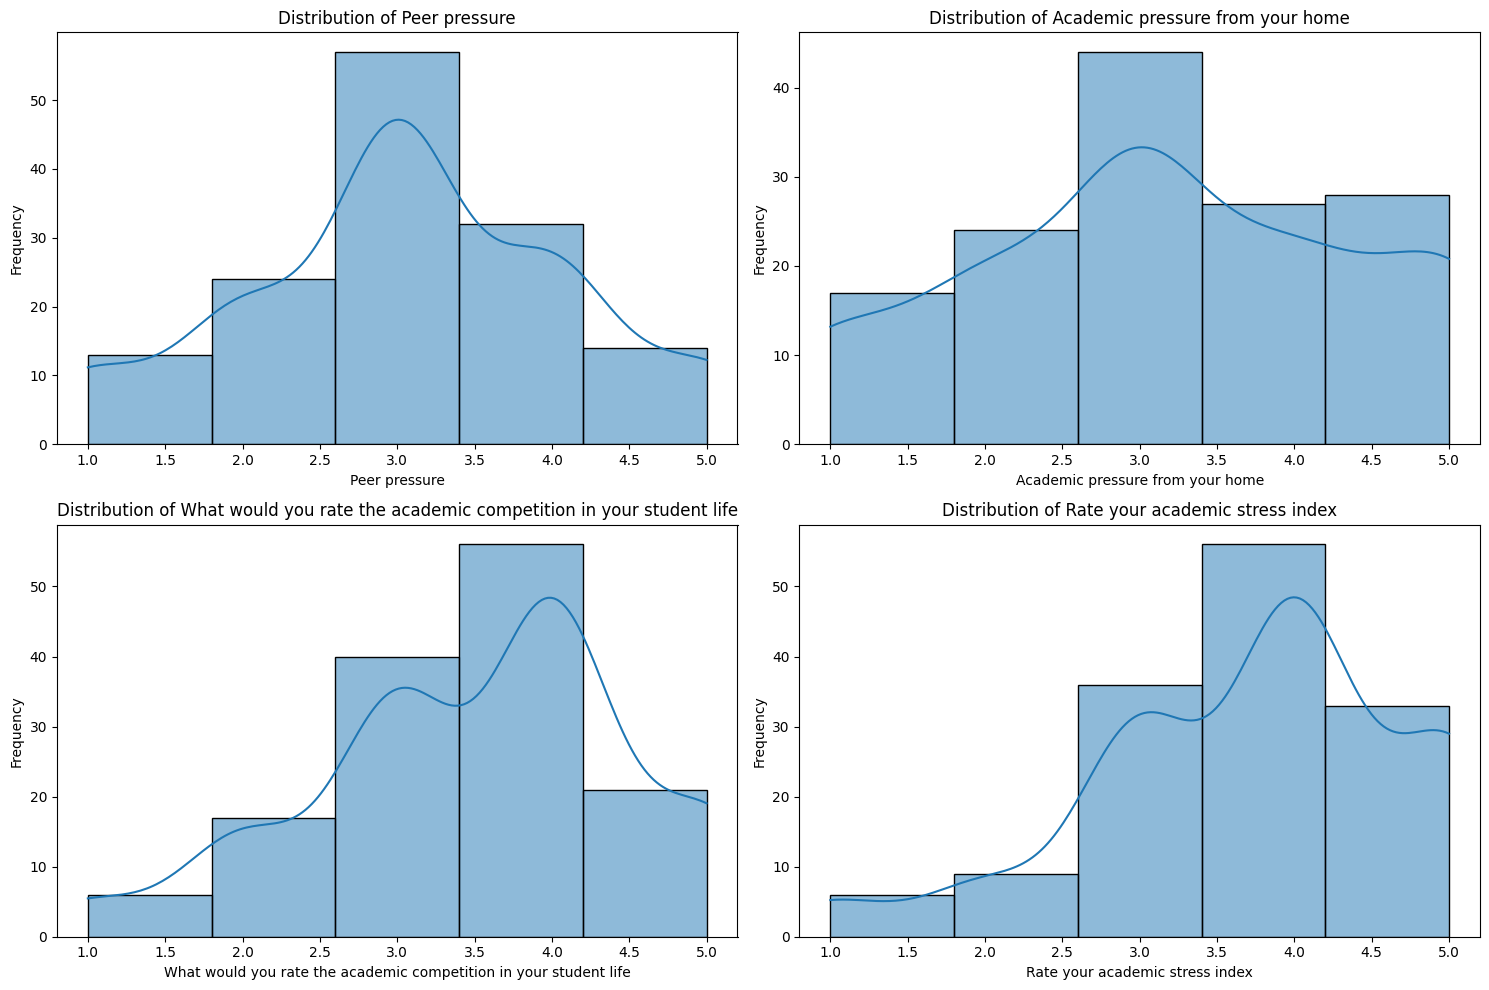

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numerical columns for distribution plotting
# Column names are adjusted to match the cleaned names after applying .str.replace(r'\s+', ' ') in the previous cell
numerical_cols = [
    'Peer pressure',
    'Academic pressure from your home',
    'What would you rate the academic competition in your student life', # Corrected single space
    'Rate your academic stress index'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i) # Arrange plots in a 2x2 grid
    sns.histplot(df_encoded[col], kde=True, bins=5)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

Now, let's look at the correlation between these numerical features to understand their relationships.

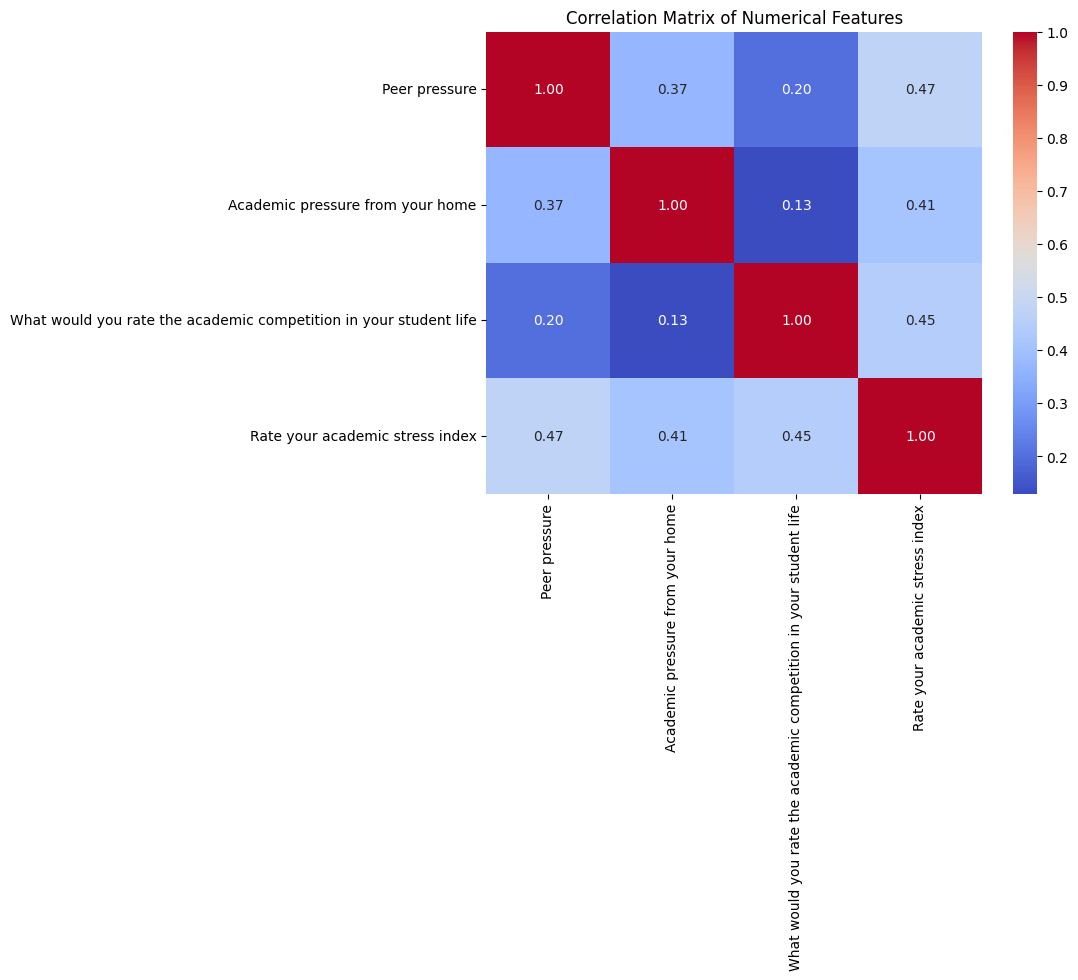

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Preparing Data for Model Training: Predicting Academic Stress Index

To predict advice for student problems, we'll train a classification model to predict the 'Rate your academic stress index'. This index ranges from 1 to 5, which we can treat as distinct classes. We will use the other relevant features in the `df_encoded` DataFrame as input to the model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Drop 'Timestamp' as it's not a feature for model training
df_model = df_encoded.drop('Timestamp', axis=1)

# Define features (X) and target (y)
# The target will be 'Rate your academic stress index'
X = df_model.drop('Rate your academic stress index', axis=1)
y = df_model['Rate your academic stress index']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (112, 11)
Testing set shape: (28, 11)


### Training the RandomForestClassifier Model

Now, we'll initialize and train a `RandomForestClassifier` using our training data. After training, we'll make predictions on the test set and evaluate the model's performance using accuracy and a classification report.

In [ ]:
# Initialize the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training complete!")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

Model training complete!

Model Accuracy: 0.21

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         2
           3       0.25      0.14      0.18         7
           4       0.21      0.27      0.24        11
           5       0.12      0.14      0.13         7

    accuracy                           0.21        28
   macro avg       0.32      0.31      0.31        28
weighted avg       0.21      0.21      0.21        28



### Analyzing Target Variable Distribution

Let's visualize the distribution of the 'Rate your academic stress index' in our training set to identify any class imbalance. This can significantly impact model performance, especially for classes with fewer samples.

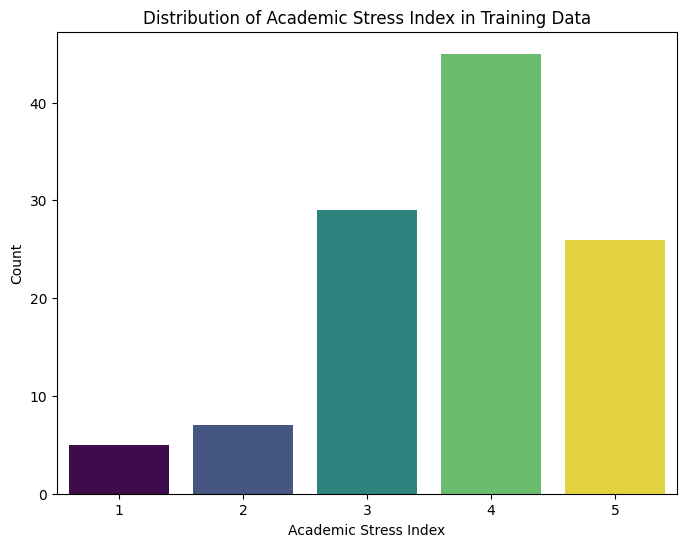

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train, palette='viridis', hue=y_train, legend=False)
plt.title('Distribution of Academic Stress Index in Training Data')
plt.xlabel('Academic Stress Index')
plt.ylabel('Count')
plt.show()

### Evaluating Model Performance with a Confusion Matrix

To get a more granular understanding of our model's performance, especially with the observed class imbalance, let's visualize the confusion matrix. This will show us how many predictions were correct for each class and where the misclassifications occurred.

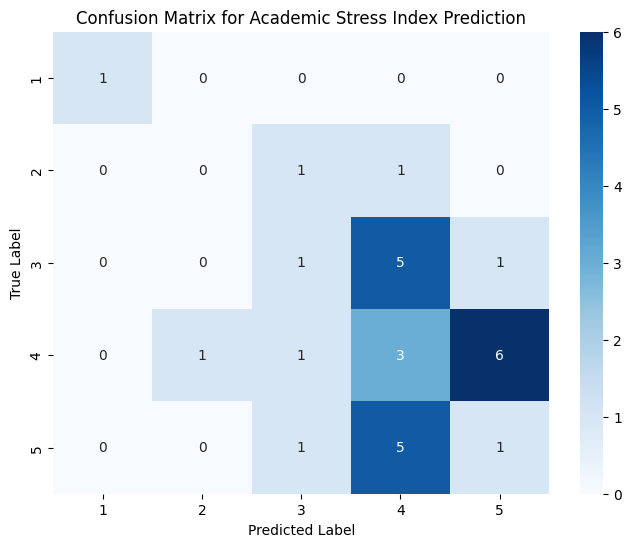

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix for Academic Stress Index Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Addressing Class Imbalance with SMOTE

As observed from the distribution plot and confirmed by the confusion matrix, our target variable `Rate your academic stress index` suffers from significant class imbalance. This often leads to models that perform poorly on minority classes.

To mitigate this, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** from the `imbalanced-learn` library. SMOTE creates synthetic samples for the minority classes, helping to balance the dataset and potentially improve the model's ability to learn from all classes.

In [ ]:
# Install imbalanced-learn if you haven't already
# !pip install imbalanced-learn
import sys

# Check if imblearn is installed, if not, install it
try:
    import imblearn
except ImportError:
    print("imblearn not found, installing...")
    %pip install imbalanced-learn
    print("imblearn installed. Please restart the runtime for changes to take effect.")
    # In a real interactive session, you'd advise the user to restart the runtime here.
    # For direct execution, we might need to import after install or rely on the next cell's execution.

# Import SMOTE
from imblearn.over_sampling import SMOTE

Now, let's apply SMOTE to our training data (`X_train`, `y_train`). This will generate synthetic samples for the minority classes, creating a more balanced dataset for model training.

In [ ]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42, k_neighbors=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape, y_train.shape}")
print(f"Resampled training set shape: {X_train_resampled.shape, y_train_resampled.shape}")

# Verify the new class distribution
print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

Original training set shape: ((112, 11), (112,))
Resampled training set shape: ((225, 11), (225,))

Class distribution after SMOTE:
Rate your academic stress index
5    45
2    45
4    45
3    45
1    45
Name: count, dtype: int64


### Retraining the Model with Resampled Data

With a balanced training set, we will now re-train the `RandomForestClassifier`. This time, the model should have a better opportunity to learn the patterns of the minority classes, potentially leading to improved accuracy and better overall performance.

In [ ]:
# Initialize a new RandomForestClassifier
model_resampled = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model with the resampled data
model_resampled.fit(X_train_resampled, y_train_resampled)

print("Model retraining with SMOTE-resampled data complete!")

# Make predictions on the original (unresampled) test set
y_pred_resampled = model_resampled.predict(X_test)

# Evaluate the new model
accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
report_resampled = classification_report(y_test, y_pred_resampled)

print(f"\nModel Accuracy (after SMOTE): {accuracy_resampled:.2f}")
print("\nClassification Report (after SMOTE):")
print(report_resampled)

Model retraining with SMOTE-resampled data complete!

Model Accuracy (after SMOTE): 0.25

Classification Report (after SMOTE):
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         2
           3       0.38      0.43      0.40         7
           4       0.27      0.27      0.27        11
           5       0.00      0.00      0.00         7

    accuracy                           0.25        28
   macro avg       0.33      0.34      0.33        28
weighted avg       0.24      0.25      0.24        28



### New Confusion Matrix (After SMOTE)

Let's visualize the confusion matrix for the retrained model to see if the predictions for the minority classes have improved.

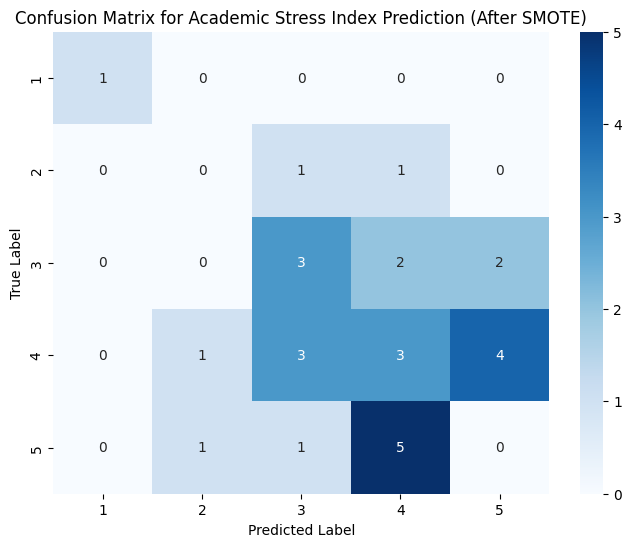

In [ ]:
# Calculate the confusion matrix for the resampled model
cm_resampled = confusion_matrix(y_test, y_pred_resampled)

# Plot the new confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=model_resampled.classes_, yticklabels=model_resampled.classes_)
plt.title('Confusion Matrix for Academic Stress Index Prediction (After SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Implementing the Student Coping Framework for Advice Generation

Now that we have a trained model to predict the academic stress index, we can use the provided framework to generate tailored advice. This involves mapping the student's characteristics and the predicted stress level to specific advice options.

We will store the framework in a Python dictionary for easy access and then create a function to generate advice for a given student's profile.

In [ ]:
import numpy as np
import pandas as pd # Import pandas here as it's used within the function

# The Student Coping Framework as a Python dictionary
advice_framework = {
    "Academic Pressure from Home": {
        "identify": ["Family expectations", "comparison with siblings", "career pressure"],
        "advice": [
            "Encourage open communication with parents.",
            "Teach boundary-setting and self-advocacy.",
            "Suggest mentorship outside the family.",
            "Promote self-worth beyond grades."
        ]
    },
    "Study Environment": {
        "identify": ["Distractions", "lack of resources", "noisy surroundings"],
        "advice": [
            "Create a quiet, organized study space.",
            "Use libraries or shared study rooms.",
            "Introduce productivity tools (Pomodoro, planners).",
            "Encourage peer study groups for motivation."
        ]
    },
    "Coping Strategies": {
        "identify": ["Stress management", "workload balance"],
        "advice": [
            "Time management (schedules, task breakdown).",
            "Relaxation techniques (breathing, meditation, short walks).",
            "Healthy lifestyle (sleep, exercise, nutrition).",
            "Reward system for completed tasks."
        ]
    },
    "Bad Habits": {
        "identify": ["Unhealthy coping mechanisms (smoking, drinking, etc.)"],
        "advice": [
            "Replace with healthier alternatives (sports, journaling, hobbies).",
            "Provide access to counseling or peer support.",
            "Track triggers and avoid them.",
            "Celebrate small wins in reducing frequency."
        ]
    },
    "Academic Competition": {
        "identify": ["Peer rivalry", "pressure to outperform"],
        "advice": [
            "Shift focus to self-improvement.",
            "Encourage collaboration over competition.",
            "Build non-academic skills for confidence.",
            "Normalize setbacks as part of growth."
        ]
    },
    "Academic Stress Index": {
        "identify": ["Stress level (low, moderate, high)"],
        "advice_levels": {
            (1, 4): "Maintain routines, stay consistent.",
            (5, 6): "Add relaxation practices, balance workload.",
            (7, 9): "Seek counseling, reduce commitments, prioritize mental health."
        },
        "general_advice": "Encourage journaling to track stress patterns."
    }
}

def generate_student_advice(student_profile, model, feature_columns, framework):
    """
    Generates personalized advice for a student based on their profile and a trained model.

    Args:
        student_profile (pd.Series): A single row of student data with feature values.
        model: The trained machine learning model to predict academic stress index.
        feature_columns (list): List of feature columns the model was trained on.
        framework (dict): The advice framework dictionary.

    Returns:
        list: A list of advice strings tailored to the student.
    """
    advice_list = []

    # Prepare student profile for prediction
    # Ensure the student_profile has all columns expected by the model in the correct order
    # Convert the sample student profile (pd.Series) to a DataFrame with correct columns
    student_features_df = pd.DataFrame([student_profile[feature_columns].values], columns=feature_columns)
    predicted_stress_index = model.predict(student_features_df)[0]
    advice_list.append(f"Predicted Academic Stress Index: {predicted_stress_index}")

    # --- Academic Stress Index Advice ---
    stress_advice_section = framework["Academic Stress Index"]
    for (lower, upper), advice in stress_advice_section["advice_levels"].items():
        if lower <= predicted_stress_index <= upper:
            advice_list.append(f"Academic Stress Index Advice: {advice}")
            break
    advice_list.append(f"Academic Stress Index General Advice: {stress_advice_section['general_advice']}")

    # --- Other Categories Advice ---
    # Academic Pressure from Home
    if 'Academic pressure from your home' in student_profile and student_profile['Academic pressure from your home'] >= 4:
        advice_list.extend([f"Academic Pressure from Home Advice: {a}" for a in framework["Academic Pressure from Home"]["advice"][:2]]) # Take 2 advice options

    # Study Environment
    # The 'Study Environment_disrupted' and 'Study Environment_Peaceful' columns are booleans after one-hot encoding
    if ('Study Environment_disrupted' in student_profile and student_profile['Study Environment_disrupted'] == True) or \
       ('Study Environment_Peaceful' in student_profile and student_profile['Study Environment_Peaceful'] == False):
        advice_list.extend([f"Study Environment Advice: {a}" for a in framework["Study Environment"]["advice"][:2]])

    # Coping Strategies (assuming the model might infer this from other features or direct input)
    # For this demonstration, we'll check for specific coping strategies identified in the one-hot encoded columns
    if 'What coping strategy you use as a student?_Emotional breakdown (crying a lot)' in student_profile and \
       student_profile['What coping strategy you use as a student?_Emotional breakdown (crying a lot)'] == True:
        advice_list.extend([f"Coping Strategies Advice: {a}" for a in framework["Coping Strategies"]["advice"][:2]])

    # Bad Habits
    if 'Do you have any bad habits like smoking, drinking on a daily basis?_Yes' in student_profile and \
       student_profile['Do you have any bad habits like smoking, drinking on a daily basis?_Yes'] == True:
        advice_list.extend([f"Bad Habits Advice: {a}" for a in framework["Bad Habits"]["advice"][:2]])

    # Academic Competition
    if 'What would you rate the academic competition in your student life' in student_profile and \
       student_profile['What would you rate the academic competition in your student life'] >= 4:
        advice_list.extend([f"Academic Competition Advice: {a}" for a in framework["Academic Competition"]["advice"][:2]])

    return advice_list

print("Advice framework loaded and advice generation function defined.")

Advice framework loaded and advice generation function defined.


### Example: Generating Advice for a Sample Student

Let's pick a random student from our test set (`X_test`) and generate advice for them using our defined framework and the trained `RandomForestClassifier` model.

In [ ]:
# Select a sample student from the test set
sample_student_index = 2 # You can change this index to try different students
sample_student_profile = X_test.iloc[sample_student_index]

# Get the feature column names that the model was trained on
feature_columns = X.columns.tolist()

# Generate advice for the sample student
student_advice = generate_student_advice(sample_student_profile, model, feature_columns, advice_framework)

print(f"Advice for Sample Student (Index: {X_test.index[sample_student_index]}):")
for advice_item in student_advice:
    print(f"- {advice_item}")


Advice for Sample Student (Index: 67):
- Predicted Academic Stress Index: 5
- Academic Stress Index Advice: Add relaxation practices, balance workload.
- Academic Stress Index General Advice: Encourage journaling to track stress patterns.
- Academic Pressure from Home Advice: Encourage open communication with parents.
- Academic Pressure from Home Advice: Teach boundary-setting and self-advocacy.
- Study Environment Advice: Create a quiet, organized study space.
- Study Environment Advice: Use libraries or shared study rooms.
- Coping Strategies Advice: Time management (schedules, task breakdown).
- Coping Strategies Advice: Relaxation techniques (breathing, meditation, short walks).


In [ ]:
import pickle

# Save the trained model
model_filename = 'random_forest_model_resampled.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model_resampled, file)

# Save the feature columns (important for consistent input to the model)
feature_columns_filename = 'feature_columns.pkl'
with open(feature_columns_filename, 'wb') as file:
    pickle.dump(feature_columns, file)

print(f"Model saved to {model_filename}")
print(f"Feature columns saved to {feature_columns_filename}")

Model saved to random_forest_model_resampled.pkl
Feature columns saved to feature_columns.pkl


### 2. Creating a Basic Streamlit Application (`app.py`)

Here's an example of `app.py` that you can create in VS Code. This script will:
1.  Load the saved model and feature columns.
2.  Provide interactive widgets for user input.
3.  Preprocess the user input to match the model's expected format.
4.  Generate a prediction and advice.
5.  Display the results.

**Instructions:**
1.  **Save the code below** into a file named `app.py` in the same directory where you saved `random_forest_model_resampled.pkl` and `feature_columns.pkl`.
2.  **Install Streamlit:** If you haven't already, run `pip install streamlit` in your terminal.
3.  **Run the app:** Open your terminal in the directory where `app.py` is located and run `streamlit run app.py`.

This will open the Streamlit app in your web browser.

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# --- Load Model and Feature Columns ---
@st.cache_resource
def load_model_and_features():
    with open('random_forest_model_resampled.pkl', 'rb') as file:
        model = pickle.load(file)
    with open('feature_columns.pkl', 'rb') as file:
        feature_columns = pickle.load(file)
    return model, feature_columns

model, feature_columns = load_model_and_features()

# --- Student Coping Framework ---
advice_framework = {
    "Academic Pressure from Home": {
        "advice": [
            "Encourage open communication with parents.",
            "Teach boundary-setting and self-advocacy.",
            "Suggest mentorship outside the family.",
            "Promote self-worth beyond grades."
        ]
    },
    "Study Environment": {
        "advice": [
            "Create a quiet, organized study space.",
            "Use libraries or shared study rooms.",
            "Introduce productivity tools (Pomodoro, planners).",
            "Encourage peer study groups for motivation."
        ]
    },
    "Coping Strategies": {
        "advice": [
            "Time management (schedules, task breakdown).",
            "Relaxation techniques (breathing, meditation, short walks).",
            "Healthy lifestyle (sleep, exercise, nutrition).",
            "Reward system for completed tasks."
        ]
    },
    "Bad Habits": {
        "advice": [
            "Replace with healthier alternatives (sports, journaling, hobbies).",
            "Provide access to counseling or peer support.",
            "Track triggers and avoid them.",
            "Celebrate small wins in reducing frequency."
        ]
    },
    "Academic Competition": {
        "advice": [
            "Shift focus to self-improvement.",
            "Encourage collaboration over competition.",
            "Build non-academic skills for confidence.",
            "Normalize setbacks as part of growth."
        ]
    },
    "Academic Stress Index": {
        "advice_levels": {
            (1, 4): "Maintain routines, stay consistent.",
            (5, 6): "Add relaxation practices, balance workload.",
            (7, 9): "Seek counseling, reduce commitments, prioritize mental health."
        },
        "general_advice": "Encourage journaling to track stress patterns."
    }
}

def generate_student_advice(student_profile, model, feature_columns, framework):
    """
    Generates personalized advice for a student based on their profile and a trained model.

    Args:
        student_profile (pd.Series): A single row of student data with feature values.
        model: The trained machine learning model to predict academic stress index.
        feature_columns (list): List of feature columns the model was trained on.
        framework (dict): The advice framework dictionary.

    Returns:
        list: A list of advice strings tailored to the student.
    """
    advice_list = []

    # Prepare student profile for prediction
    # Ensure the student_profile has all columns expected by the model in the correct order
    # Convert the sample student profile (pd.Series) to a DataFrame with correct columns
    student_features_df = pd.DataFrame([student_profile[feature_columns].values], columns=feature_columns)
    predicted_stress_index = model.predict(student_features_df)[0]
    advice_list.append(f"Predicted Academic Stress Index: {predicted_stress_index}")

    # --- Academic Stress Index Advice ---
    stress_advice_section = framework["Academic Stress Index"]
    for (lower, upper), advice in stress_advice_section["advice_levels"].items():
        if lower <= predicted_stress_index <= upper:
            advice_list.append(f"Academic Stress Index Advice: {advice}")
            break
    advice_list.append(f"Academic Stress Index General Advice: {stress_advice_section['general_advice']}")

    # --- Other Categories Advice ---
    # Academic Pressure from Home
    if 'Academic pressure from your home' in student_profile and student_profile['Academic pressure from your home'] >= 4:
        advice_list.extend([f"Academic Pressure from Home Advice: {a}" for a in framework["Academic Pressure from Home"]["advice"][:2]]) # Take 2 advice options

    # Study Environment
    # The 'Study Environment_disrupted' and 'Study Environment_Peaceful' columns are booleans after one-hot encoding
    if ('Study Environment_disrupted' in student_profile and student_profile['Study Environment_disrupted'] == True) or \
       ('Study Environment_Peaceful' in student_profile and student_profile['Study Environment_Peaceful'] == False):
        advice_list.extend([f"Study Environment Advice: {a}" for a in framework["Study Environment"]["advice"][:2]])

    # Coping Strategies (assuming the model might infer this from other features or direct input)
    # For this demonstration, we'll check for specific coping strategies identified in the one-hot encoded columns
    if 'What coping strategy you use as a student?_Emotional breakdown (crying a lot)' in student_profile and \
       student_profile['What coping strategy you use as a student?_Emotional breakdown (crying a lot)'] == True:
        advice_list.extend([f"Coping Strategies Advice: {a}" for a in framework["Coping Strategies"]["advice"][:2]])

    # Bad Habits
    if 'Do you have any bad habits like smoking, drinking on a daily basis?_Yes' in student_profile and \
       student_profile['Do you have any bad habits like smoking, drinking on a daily basis?_Yes'] == True:
        advice_list.extend([f"Bad Habits Advice: {a}" for a in framework["Bad Habits"]["advice"][:2]])

    # Academic Competition
    if 'What would you rate the academic competition in your student life' in student_profile and \
       student_profile['What would you rate the academic competition in your student life'] >= 4:
        advice_list.extend([f"Academic Competition Advice: {a}" for a in framework["Academic Competition"]["advice"][:2]])

    return advice_list


# --- Religion Quotes ---
religion_quotes = {
    "Hindu": "“You have the right to perform your prescribed duties, but you are not entitled to the fruits of your actions.” — Bhagavad Gita 2:47",
    "Buddhist": "“Hatred does not cease by hatred, but only by love; this is the eternal rule.” — Dhammapada 5",
    "Sikh": "“There is but One God. His name is Truth.” — Guru Granth Sahib, Mool Mantar",
    "Muslim": "“Indeed, with hardship comes ease.” — Qur'an 94:6",
    "Christian": "“Love your neighbor as yourself.” — Mark 12:31",
    "Jain": "“Non-violence is the highest religion.” — Tattvartha Sutra, Chapter 7",
    "Other": "“Wisdom is found in many paths; seek truth with compassion.”",
    "Prefer not to say": "“Peace begins with understanding ourselves.”"
}

# --- Streamlit Layout ---
st.set_page_config(page_title="Student Stress Advisor", layout="wide")
st.title("Student Academic Stress Advisor")
st.markdown("Enter student details to get personalized advice.")

# --- Student Information ---
st.header("Student Information")
student_name = st.text_input("Enter your name")
student_age = st.number_input("Enter your age", min_value=10, max_value=100, step=1)
student_gender = st.radio("Select your gender", ["Male", "Female", "Other", "Prefer not to say"])
student_religion = st.selectbox(
    "Select your religion",
    ["Hindu", "Buddhist", "Sikh", "Muslim", "Christian", "Jain", "Other", "Prefer not to say"]
)

st.markdown(" devoting")

# --- Academic Questions ---
st.header("Identify Your Challenges")

pressure_options_map = {"Very Low (1)": 1, "Low (2)": 2, "Moderate (3)": 3, "High (4)": 4, "Very High (5)": 5}
competition_options_map = {"Very Low (1)": 1, "Low (2)": 2, "Moderate (3)": 3, "High (4)": 4, "Very High (5)": 5}

peer_pressure_text = st.selectbox("Peer pressure", list(pressure_options_map.keys()), index=2)
peer_pressure = pressure_options_map[peer_pressure_text]

academic_pressure_home_text = st.selectbox("Academic pressure from your home", list(pressure_options_map.keys()), index=2)
academic_pressure_home = pressure_options_map[academic_pressure_home_text]

academic_competition_text = st.selectbox("What would you rate the academic competition in your student life", list(competition_options_map.keys()), index=2)
academic_competition = competition_options_map[academic_competition_text]

with st.sidebar:
    st.header("Additional Student Details")
    academic_stage = st.selectbox("Your Academic Stage", ['undergraduate', 'post-graduate', 'graduate'], index=0)
    study_environment = st.selectbox("Study Environment", ['Peaceful', 'noisy', 'disrupted'], index=0)
    coping_strategy = st.selectbox("What coping strategy you use as a student?", ['Emotional breakdown (crying a lot)', 'Social support (friends, family)', 'Time management', 'Healthy lifestyle'], index=1)
    bad_habits = st.selectbox("Do you have any bad habits like smoking, drinking on a daily basis?", ['No', 'Yes', 'prefer not to say'], index=0)

# --- Preprocess Input ---
def preprocess_input(
    peer_pressure, academic_pressure_home, academic_competition,
    academic_stage, study_environment, coping_strategy, bad_habits,
    feature_columns
):
    data = {
        'Peer pressure': [peer_pressure],
        'Academic pressure from your home': [academic_pressure_home],
        'What would you rate the academic competition in your student life': [academic_competition],
        'Your Academic Stage': [academic_stage],
        'Study Environment': [study_environment],
        'What coping strategy you use as a student?': [coping_strategy],
        'Do you have any bad habits like smoking, drinking on a daily basis?': [bad_habits]
    }
    input_df = pd.DataFrame(data)
    categorical_cols = ['Your Academic Stage','Study Environment','What coping strategy you use as a student?','Do you have any bad habits like smoking, drinking on a daily basis?']
    processed_df = pd.get_dummies(input_df, columns=categorical_cols, drop_first=True)
    final_input = pd.DataFrame(0, index=[0], columns=feature_columns)
    for col in processed_df.columns:
        if col in final_input.columns:
            final_input[col] = processed_df[col].iloc[0]
    for col in final_input.columns:
        if final_input[col].dtype == 'uint8':
            final_input[col] = final_input[col].astype(bool)
    return final_input.iloc[0]

# --- Advice Button ---
if st.button("Get Advice"):
    student_profile_processed = preprocess_input(
        peer_pressure, academic_pressure_home, academic_competition,
        academic_stage, study_environment, coping_strategy, bad_habits,
        feature_columns
    )
    advice = generate_student_advice(student_profile_processed, model, feature_columns, advice_framework)

    st.subheader(f"Personalized Advice for {student_name if student_name else 'Student'}")
    st.write(f"Age: {student_age}, Gender: {student_gender}")

    for item in advice:
        st.write(f"- {item}")

    if student_religion in religion_quotes:
        st.subheader("Spiritual Guidance")
        st.write(religion_quotes[student_religion])

Overwriting app.py
